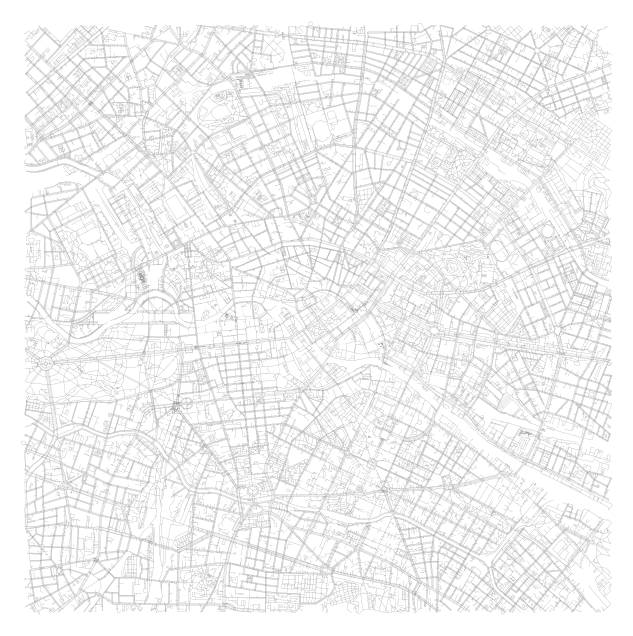

In [4]:
import osmnx as osm

berlin_rn = osm.graph_from_point((52.520008,13.404954), simplify = True, dist = 4000)

_,axis1 = osm.plot_graph(berlin_rn, node_size=0,edge_linewidth=0.09, bgcolor='white', show=True)


In [21]:
# parse the frequent maximal polylines
import os
import utm
class Trajectory:
    def __init__(self):
        self.points = []
        self.ids = []
        self.beginnings = {}
    
    def push_back(self, coords, id):
        if len(self.points)> 0:
            
            if id != self.ids[-1]:
                self.beginnings[id] = len(self.points) - 1
    
        else:
            self.beginnings[id] = 0
        
        self.points.append(coords)
        self.ids.append(id)
        
    
    def get_x_coord_at(self,idx):

        return self.points[idx][0]
    
    def get_y_coord_at(self,idx):

        return self.points[idx][1]
    
    # return list of tuples
    def get_pathlet_points(self, beginning, end, id)-> list:

        start_offset = self.beginnings[id] + beginning
        end_offset = self.beginnings[id] + end 

        l = []
        
        for i in range(start_offset, end_offset + 1):
            l.append(self.points[i])

        return l

def get_polyline_string(l) -> str:

    s = "MULTILINESTRING(("

    for i in range(0, len(l)):
        s += f"{l[i][1]} {l[i][0]}"

        if i < len(l) - 1:
            s+= ","
    
    s += "))"

    return s


def load_trajectory_from_file(file)-> Trajectory:
    
    t = Trajectory()
    assert os.path.exists(file)
    if os.path.exists(file):

        with open(file, 'r') as handle:
            for line in handle:
                point_line = line.split(" ")

                id = int(point_line[-1])
                #print(id)

                coords = tuple(map(float, (point_line[:-1])))

                coords = utm.to_latlon(coords[0], coords[1],33,'W')
                #print(coords)
                t.push_back(coords, id)
    
    return t

def generate_polyline_column(t, pathlet_file, threshold)->list:

    #for each pathlet in the file, whose frequency is above threshold

    l=[]
    with open(pathlet_file, 'r') as file:
        for line in file:

            pathlet_data = line.rstrip().split(" ")

            if float(pathlet_data[-1])> threshold:
                ### If the pathlet is shorther than 3 replicate the last point many times so that gpd doesn't complain
                points = t.get_pathlet_points(int(pathlet_data[0]), int(pathlet_data[1]), int(pathlet_data[2]))
                if( len(points) < 4):
                    continue

                l.append(get_polyline_string(points))

    return l



['MULTILINESTRING((13.390944417266178 52.525358072120994,13.393638102171415 52.52464192631886,13.400054931572015 52.52285969972466,13.403472900365026 52.52150065022318))', 'MULTILINESTRING((13.398583984367807 52.51752929612379,13.400360107373725 52.517968749218156,13.399971516871705 52.519335936720516,13.39811604816557 52.51958007731587,13.396250406864837 52.51986490811638))', 'MULTILINESTRING((13.40322265616489 52.52132975181793,13.404195149669656 52.52246907472022,13.403084309872524 52.5231119784171,13.40097249346047 52.52347005131594))', 'MULTILINESTRING((13.407639567064589 52.51810709562374,13.405332438171605 52.51971842371939,13.403389485663064 52.521085611220215,13.403749593063523 52.52289225182355))', 'MULTILINESTRING((13.39988810217361 52.5227213534221,13.40169474277281 52.521053059117584,13.403027343767393 52.521525064323505,13.403944905565089 52.52303059822306))', 'MULTILINESTRING((13.406715901671571 52.524983723218604,13.40388793946604 52.52583007732348,13.403055826771983 52

/home/maryf/FreqST/freqst_utils/lib/python3.12/site-packages/pyproj/crs/crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)


<Axes: >

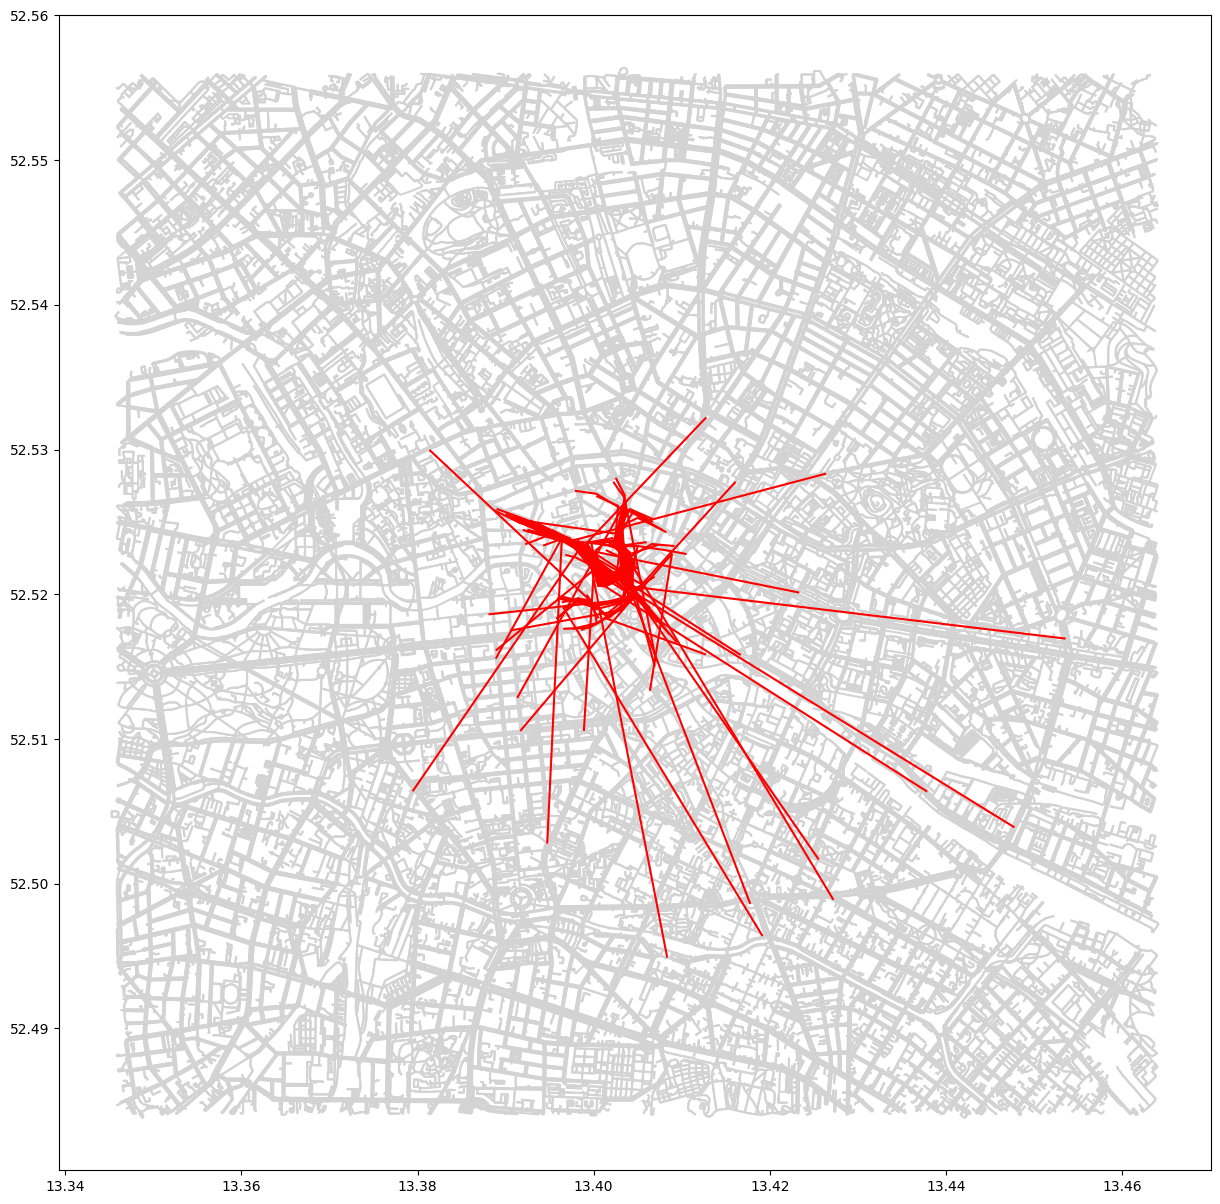

In [23]:
import pandas as pd 
import geopandas as gpd
from shapely import wkt 

pathlet_number = 10
#axis1 = osm.plot_graph(berlin_rn, node_size=0,edge_linewidth=0.09, bgcolor='white', show=True)
berlin_gdf = osm.convert.graph_to_gdfs(berlin_rn) #set CRS
#ax1 = berlin_gdf[0].plot(marker='o', markersize=0.01, color='lightgrey', zorder=2)
ax1 = berlin_gdf[1].plot(edgecolor='lightgray', zorder=1, figsize=(20, 15))
t = load_trajectory_from_file("./berlin/merged.txt")

#print(t.beginnings)
pathlet_beginning = 0
pathlet_end = 5
pathlet_mother = 3

l = t.get_pathlet_points(pathlet_beginning,pathlet_end, pathlet_mother)

# create dataframe of the 2 polygons
polyline_column = generate_polyline_column(t, "berlin/results/chernoff_0.15_0.025_0_1200_0.5.txt", 0.55)
print(polyline_column)
d = {'col1': range(0, len(polyline_column)), 'wkt': polyline_column}
df = pd.DataFrame( data=d )

# make geo-dataframe from it
geometry = [wkt.loads(pgon) for pgon in df.wkt]
gdf2 = gpd.GeoDataFrame(df, \
                   crs={'init': 'epsg:4326'}, \
                   geometry=geometry)

# plot it as red polygons
gdf2.plot(ax=ax1, color='red', zorder=5)


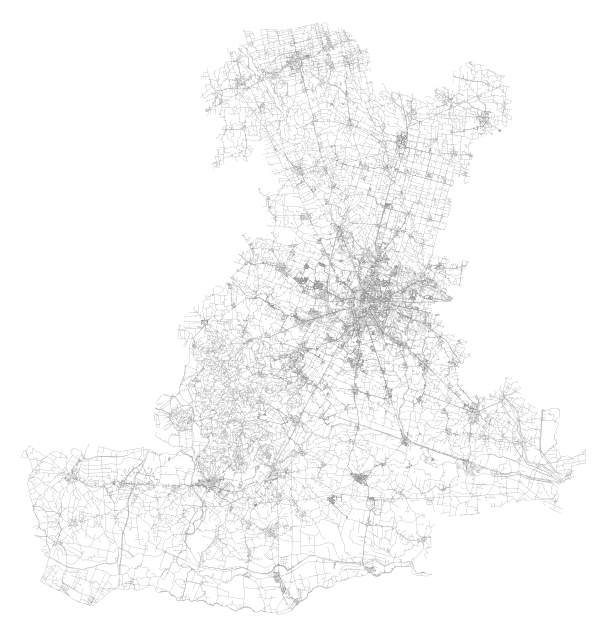

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [2]:
osm.plot_graph(padova_rn, node_size=0, edge_linewidth=0.09, bgcolor='white', show=True)